In [6]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install -q unsloth
else:

    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install -q --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install -q sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install -q --no-deps unsloth

!pip install -q transformers==4.55.4
!pip install -q --no-deps trl==0.22.2
!pip install -q evaluate rouge-score bert-score matplotlib



In [7]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
import torch, random, numpy as np

SEED = 3407
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME  = "unsloth/Qwen3-4B-Instruct-2507"
MAX_SEQ_LEN = 2048


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-09-22 18:15:12.288878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758564912.547342      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758564912.618916      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🦥 Unsloth Zoo will now patch everything to make training faster!


In [9]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name        = MODEL_NAME,
    max_seq_length    = MAX_SEQ_LEN,
    load_in_4bit      = True,
    load_in_8bit      = False,
    full_finetuning   = False,
    trust_remote_code = True,
)


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.9.7: Fast Qwen3 patching. Transformers: 4.55.4.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,
    target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
    use_rslora = False,
    loftq_config = None,
)


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [11]:
tokenizer = get_chat_template(tokenizer, chat_template="qwen3-instruct")

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [12]:
for impl in ("flash_attention_2", "sdpa"):
    try:
        model.config.attn_implementation = impl
        break
    except Exception:
        pass

print("Attention impl:", getattr(model.config, "attn_implementation", "default"))
print("Pad token:", tokenizer.pad_token, f"(id={tokenizer.pad_token_id})")


Attention impl: flash_attention_2
Pad token: <|vision_pad|> (id=151654)


In [3]:
from datasets import load_dataset

ds = load_dataset("abisee/cnn_dailymail", '1.0.0')
for split in ds:
    print(f"{split}: {len(ds[split])} rows")

print({k: ds[k].column_names for k in ds})


README.md: 0.00B [00:00, ?B/s]

1.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

1.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

1.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

1.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

1.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

train: 287113 rows
validation: 13368 rows
test: 11490 rows
{'train': ['article', 'highlights', 'id'], 'validation': ['article', 'highlights', 'id'], 'test': ['article', 'highlights', 'id']}


In [5]:
display(ds["train"][0])

{'article': 'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office char

In [13]:
from datasets import DatasetDict
import random, textwrap

assert isinstance(ds, DatasetDict), "Expected ds from load_dataset(...)"


print("Split sizes:", {k: len(v) for k, v in ds.items()})


print("Columns per split:", {k: v.column_names for k, v in ds.items()})

def peek(split="train", n=2, width=110):
    print(f"\n--- Peek {split} ---")
    for _ in range(n):
        i = random.randrange(len(ds[split]))
        ex = ds[split][i]
        print(f"# idx={i} | article chars={len(ex['article'])} | highlights chars={len(ex['highlights'])}")
        print("ARTICLE:")
        print(textwrap.shorten(ex["article"].replace("\n"," "), width=width))
        print("HIGHLIGHTS:")
        print(textwrap.shorten(ex["highlights"].replace("\n"," "), width=width))
        print("-"*width)

peek("train", n=2)
peek("validation", n=1)
peek("test", n=1)


Split sizes: {'train': 287113, 'validation': 13368, 'test': 11490}
Columns per split: {'train': ['article', 'highlights', 'id'], 'validation': ['article', 'highlights', 'id'], 'test': ['article', 'highlights', 'id']}

--- Peek train ---
# idx=29798 | article chars=5326 | highlights chars=301
ARTICLE:
WASHINGTON (CNN) -- It took a U.S. former president with global celebrity status to free two American [...]
HIGHLIGHTS:
Former President Clinton talked with national security adviser before trip . Clinton made it clear that [...]
--------------------------------------------------------------------------------------------------------------
# idx=219838 | article chars=8206 | highlights chars=321
ARTICLE:
Amazing photographs, captured in vivid colour, show life in Russia in the early 1900’s as the country [...]
HIGHLIGHTS:
Colour photographs from one of Russia's most famous photographers, Sergey Prokudin-Gorsky . Tsar [...]
--------------------------------------------------------------------

In [14]:
import re
ws_only = re.compile(r"^\s*$")

def qc_counts(dset):
    n = len(dset)
    empty_article = sum(1 for t in dset["article"] if ws_only.match(t or ""))
    empty_high    = sum(1 for t in dset["highlights"] if ws_only.match(t or ""))
    very_short_a  = sum(1 for t in dset["article"] if len((t or "").strip()) < 50)
    very_short_h  = sum(1 for t in dset["highlights"] if len((t or "").strip()) < 10)
    return {
        "rows": n,
        "empty_article": empty_article,
        "empty_highlights": empty_high,
        "very_short_article(<50ch)": very_short_a,
        "very_short_highlights(<10ch)": very_short_h,
    }

for split in ds:
    print(split, qc_counts(ds[split]))


train {'rows': 287113, 'empty_article': 0, 'empty_highlights': 0, 'very_short_article(<50ch)': 1, 'very_short_highlights(<10ch)': 0}
validation {'rows': 13368, 'empty_article': 0, 'empty_highlights': 0, 'very_short_article(<50ch)': 0, 'very_short_highlights(<10ch)': 0}
test {'rows': 11490, 'empty_article': 0, 'empty_highlights': 0, 'very_short_article(<50ch)': 0, 'very_short_highlights(<10ch)': 0}


In [15]:
import re
_html = re.compile(r"<[^>]+>")
_special_chars = re.compile(r"[^a-zA-Z0-9\s.,!?'\"()]") 

def clean_text(s: str) -> str:
    if s is None: return ""
    s = _html.sub(" ", s)
    s = _special_chars.sub(" ", s) 
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_map(row):
    row["article"]    = clean_text(row["article"])
    row["highlights"] = clean_text(row["highlights"])
    return row

In [16]:
from datasets import DatasetDict

ds_clean = DatasetDict()

for split in ds:
    d = ds[split].map(clean_map, desc=f"Cleaning {split}")
    d = d.filter(lambda r: len(r["article"]) > 0 and len(r["highlights"]) > 0,
                 desc=f"Filter empties {split}")

   
    seen = set()
    def _not_seen(r):
        key = (r["article"], r["highlights"])
        if key in seen: return False
        seen.add(key); return True

    d = d.filter(_not_seen, desc=f"Dedup {split}")
    ds_clean[split] = d

print("After cleaning:", {k: len(v) for k, v in ds_clean.items()})

Cleaning train:   0%|          | 0/287113 [00:00<?, ? examples/s]

Filter empties train:   0%|          | 0/287113 [00:00<?, ? examples/s]

Dedup train:   0%|          | 0/287113 [00:00<?, ? examples/s]

Cleaning validation:   0%|          | 0/13368 [00:00<?, ? examples/s]

Filter empties validation:   0%|          | 0/13368 [00:00<?, ? examples/s]

Dedup validation:   0%|          | 0/13368 [00:00<?, ? examples/s]

Cleaning test:   0%|          | 0/11490 [00:00<?, ? examples/s]

Filter empties test:   0%|          | 0/11490 [00:00<?, ? examples/s]

Dedup test:   0%|          | 0/11490 [00:00<?, ? examples/s]

After cleaning: {'train': 284013, 'validation': 13368, 'test': 11488}


In [17]:

import numpy as np
import matplotlib.pyplot as plt

def token_lengths(texts, tok, limit=None):
    out = []
    for i, t in enumerate(texts):
        if limit is not None and i >= limit: break
        out.append(len(tok(t, add_special_tokens=False).input_ids))
    return out

def describe_tokens(name, lens):
    if not lens:
        print(f"{name}: no data"); return
    a = np.array(lens)
    print(f"{name:>22} | mean={a.mean():.1f} | median={np.median(a):.1f} "
          f"| p90={np.percentile(a,90):.1f} | p95={np.percentile(a,95):.1f} | max={a.max()}")

def plot_hist(lens, title, bins=60):
    plt.figure()
    plt.hist(lens, bins=bins)
    plt.title(title)
    plt.xlabel("tokens")
    plt.ylabel("count")
    plt.show()



=== TRAIN (sample up to 70000) ===
        tokens/article | mean=812.7 | median=747.0 | p90=1394.0 | p95=1620.0 | max=3638
     tokens/highlights | mean=56.3 | median=56.0 | p90=73.0 | p95=77.0 | max=116


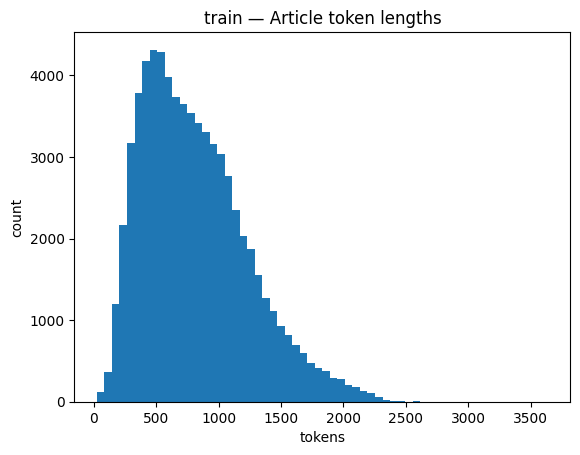

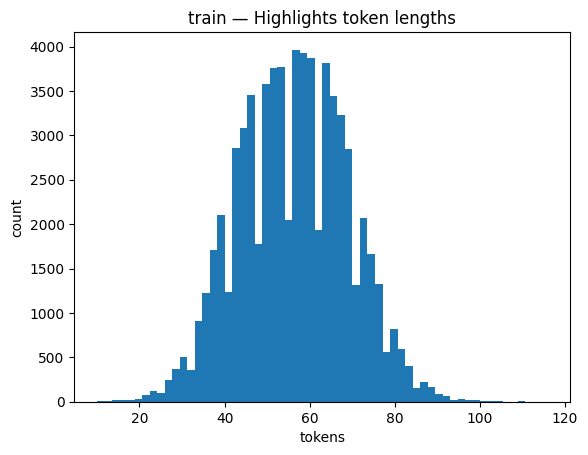

ratio(highlights/article) | mean=0.091 | median=0.076 | p90=0.159 | p95=0.194

=== VALIDATION (sample up to 70000) ===
        tokens/article | mean=844.2 | median=757.0 | p90=1456.0 | p95=1718.6 | max=2603
     tokens/highlights | mean=71.3 | median=66.0 | p90=107.0 | p95=122.6 | max=1879


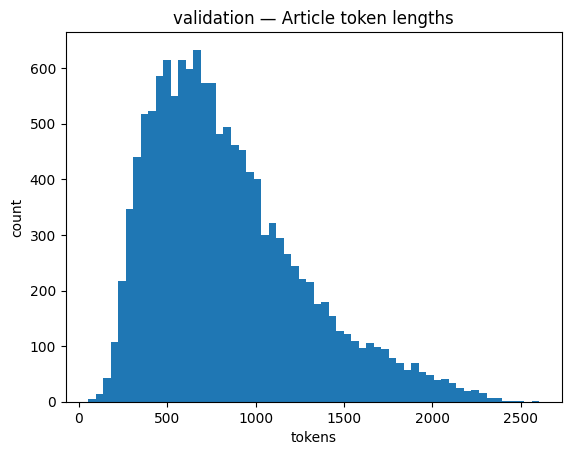

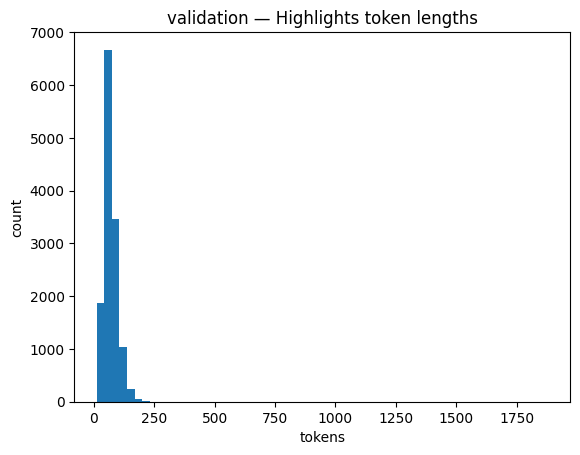

ratio(highlights/article) | mean=0.103 | median=0.091 | p90=0.174 | p95=0.208

=== TEST (sample up to 70000) ===
        tokens/article | mean=856.1 | median=767.0 | p90=1487.0 | p95=1745.0 | max=2994
     tokens/highlights | mean=67.9 | median=63.0 | p90=101.0 | p95=118.0 | max=864


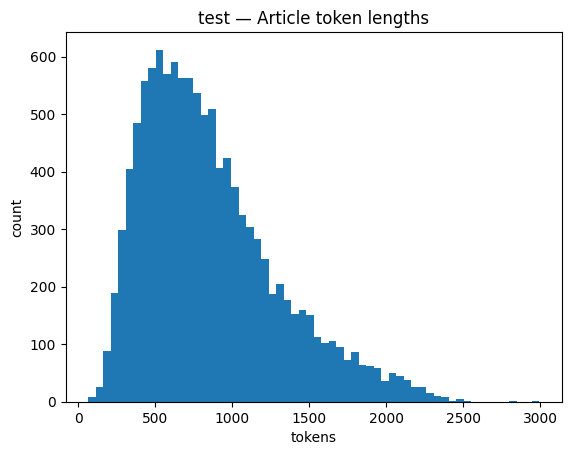

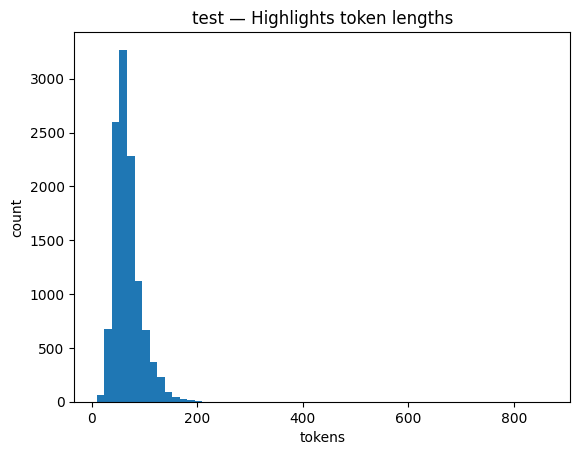

ratio(highlights/article) | mean=0.099 | median=0.085 | p90=0.168 | p95=0.201


In [15]:

LIMIT =70000

stats = {}
for split in ["train", "validation", "test"]:
    a_lens = token_lengths(ds_clean[split]["article"],    tokenizer, limit=LIMIT)
    h_lens = token_lengths(ds_clean[split]["highlights"], tokenizer, limit=LIMIT)
    print(f"\n=== {split.upper()} (sample up to {LIMIT}) ===")
    describe_tokens("tokens/article", a_lens)
    describe_tokens("tokens/highlights", h_lens)
    plot_hist(a_lens, f"{split} — Article token lengths")
    plot_hist(h_lens, f"{split} — Highlights token lengths")

    ratios = [h/a for h, a in zip(h_lens, a_lens) if a > 0]
    if ratios:
        r = np.array(ratios)
        print(f"ratio(highlights/article) | mean={r.mean():.3f} | median={np.median(r):.3f} "
              f"| p90={np.percentile(r,90):.3f} | p95={np.percentile(r,95):.3f}")


In [18]:
MAX_SEQ_LEN = getattr(model.config, "max_position_embeddings", 2048) or 2048
PROMPT_OVERHEAD = 64    
ASSIST_MAX_TOK  = 256    
ARTICLE_BUDGET  = max(256, MAX_SEQ_LEN - PROMPT_OVERHEAD - ASSIST_MAX_TOK)

print(f"Budgets  | MAX_SEQ_LEN={MAX_SEQ_LEN} | ARTICLE_BUDGET={ARTICLE_BUDGET} | ASSIST_MAX_TOK={ASSIST_MAX_TOK}")

def pct_fit_article(dset, budget, limit=20000):
    a_lens = token_lengths(dset["article"], tokenizer, limit=limit)
    if not a_lens: return 0.0
    ok = sum(1 for L in a_lens if L <= budget)
    return 100.0 * ok / len(a_lens)

for split in ["train", "validation", "test"]:
    p = pct_fit_article(ds_clean[split], ARTICLE_BUDGET, limit=20000)
    print(f"{split:>10} | % articles that fit ARTICLE_BUDGET: {p:.1f}%")


Budgets  | MAX_SEQ_LEN=262144 | ARTICLE_BUDGET=261824 | ASSIST_MAX_TOK=256
     train | % articles that fit ARTICLE_BUDGET: 100.0%
validation | % articles that fit ARTICLE_BUDGET: 100.0%
      test | % articles that fit ARTICLE_BUDGET: 100.0%


In [19]:
%pip install langdetect

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.9 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e73aba35da1066975ff8a88316f8d026d83612e41bfe9c23a127d76d507e182f
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
Note: you may need to restart the kernel to use updated packages.


In [19]:
from langdetect import detect
from tqdm.auto import tqdm

try:
    detect("This is a test sentence.")
except:
    %pip install langdetect
    from langdetect import detect

def detect_language(text):
    try:
        return detect(text)
    except:

        return "unknown"


sample_size = ds_clean["train"].num_rows

train_clean = ds_clean["train"]
non_english_articles = []

print(f"Checking the first {sample_size} articles for non-English languages...")
for i in tqdm(range(min(sample_size, len(train_clean)))):
    article = train_clean[i]["article"]
    lang = detect_language(article)
    if lang != "en":
        non_english_articles.append({"index": i, "language": lang, "article_start": article[:100] + "..."})

if non_english_articles:
    print("\nFound non-English articles:")
    for item in non_english_articles:
        print(f"Index: {item['index']}, Language: {item['language']}, Article start: {item['article_start']}")
else:
    print("\nNo non-English articles found in the sample.")

Checking the first 284013 articles for non-English languages...


  0%|          | 0/284013 [00:00<?, ?it/s]


Found non-English articles:
Index: 76576, Language: vi, Article start: (CNN) 3.1415926535897932384626433832795028 . 84197169399375105820974944592307816 . 40628620899862803...


In [20]:
MAX_SEQ_LEN_TRAIN = 2048
PROMPT_OVERHEAD   = 64
ASSIST_MAX_TOK    = 256
ARTICLE_BUDGET_TRAIN = max(256, MAX_SEQ_LEN_TRAIN - PROMPT_OVERHEAD - ASSIST_MAX_TOK)

print(f"TRAIN budgets | MAX_SEQ_LEN_TRAIN={MAX_SEQ_LEN_TRAIN} "
      f"| ARTICLE_BUDGET_TRAIN={ARTICLE_BUDGET_TRAIN} | ASSIST_MAX_TOK={ASSIST_MAX_TOK}")


TRAIN budgets | MAX_SEQ_LEN_TRAIN=2048 | ARTICLE_BUDGET_TRAIN=1728 | ASSIST_MAX_TOK=256


In [22]:
def _trim_tokens(text: str, budget: int) -> str:
    ids = tokenizer(text, add_special_tokens=False).input_ids
    return text if len(ids) <= budget else tokenizer.decode(ids[:budget], skip_special_tokens=True)


In [23]:
SYSTEM_PROMPT = (
    "You are a reliable news summarization assistant. "
    "Given an article, write a concise summary for the highlights in the article for a general audience. "
    "Do not hallucinate or add details that are not stated in the article."
)


In [24]:
from datasets import DatasetDict

base_ds = ds_clean 

def to_conversation(row):
    art = _trim_tokens(row["article"], ARTICLE_BUDGET_TRAIN)
    return {
        "conversations": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"Summarize the following article:\n\n{art}"},
            {"role": "assistant", "content": row["highlights"]},  
        ]
    }

train_conv = base_ds["train"].map(to_conversation, desc="Build chat rows (train)")
val_conv   = base_ds["validation"].map(to_conversation, desc="Build chat rows (val)")
test_raw   = base_ds["test"] 

print("Built conversations:", len(train_conv), len(val_conv), len(test_raw))


Build chat rows (train):   0%|          | 0/284013 [00:00<?, ? examples/s]

Build chat rows (val):   0%|          | 0/13368 [00:00<?, ? examples/s]

Built conversations: 284013 13368 11488


In [25]:
from unsloth.chat_templates import standardize_data_formats

train_conv = standardize_data_formats(train_conv)
val_conv   = standardize_data_formats(val_conv)

def formatting_prompts_func(batch):
    convos = batch["conversations"]
    texts = [
        tokenizer.apply_chat_template(
            c,
            tokenize=False,
            add_generation_prompt=False,
        )
        for c in convos
    ]
    return {"text": texts}

train_text = train_conv.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=train_conv.column_names,
    desc="Apply chat template (train)",
)

val_text = val_conv.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=val_conv.column_names,
    desc="Apply chat template (val)",
)

print("Prepared:", len(train_text), "train |", len(val_text), "val")


Unsloth: Standardizing formats (num_proc=4):   0%|          | 0/284013 [00:00<?, ? examples/s]

Unsloth: Standardizing formats (num_proc=4):   0%|          | 0/13368 [00:00<?, ? examples/s]

Apply chat template (train):   0%|          | 0/284013 [00:00<?, ? examples/s]

Apply chat template (val):   0%|          | 0/13368 [00:00<?, ? examples/s]

Prepared: 284013 train | 13368 val


In [26]:
idx = 0
print(train_text[idx]["text"][:800])


<|im_start|>system
You are a reliable news summarization assistant. Given an article, write a concise summary for the highlights in the article for a general audience. Do not hallucinate or add details that are not stated in the article.<|im_end|>
<|im_start|>user
Summarize the following article:

LONDON, England (Reuters) Harry Potter star Daniel Radcliffe gains access to a reported 20 million ( 41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon a


In [30]:
import torch

BF16_OK = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
FP16_OK = not BF16_OK

assert "text" in train_text.column_names, "train_text must contain a 'text' column."
assert "text" in val_text.column_names,   "val_text must contain a 'text' column."

print(f"bf16={BF16_OK} | fp16={FP16_OK} | cuda={torch.cuda.is_available()}")


bf16=False | fp16=True | cuda=True


In [ ]:
import torch

BF16_OK = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
FP16_OK = not BF16_OK

capability = (0, 0)
if torch.cuda.is_available():
    try:
        capability = torch.cuda.get_device_capability()
    except Exception:
        pass

use_tf32 = torch.cuda.is_available() and capability[0] >= 8

optim_choice = "adamw_8bit" if torch.cuda.is_available() else "adamw_torch"

print(f"CUDA available: {torch.cuda.is_available()} | device capability: {capability} | use_tf32={use_tf32}")
print(f"Precision flags → bf16={BF16_OK}, fp16={FP16_OK}")
print(f"Optimizer: {optim_choice}")


CUDA available: True | device capability: (7, 5) | use_tf32=False
Precision flags → bf16=False, fp16=True
Optimizer: adamw_8bit


In [ ]:
from trl import SFTConfig

try:
    max_seq_len_for_trainer = MAX_SEQ_LEN_TRAIN 
except NameError:
    max_seq_len_for_trainer = getattr(model.config, "max_position_embeddings", 2048) or 2048

sft_args = SFTConfig(
    dataset_text_field = "text",
    output_dir = "qwen3_unsloth_cnn_dm_lora",
    max_seq_length = max_seq_len_for_trainer,   
    per_device_train_batch_size = 2,            
    gradient_accumulation_steps = 4,            
    warmup_steps = 5,
    num_train_epochs = 2,                    
    max_steps = 60,                           
    learning_rate = 2e-4,
    logging_steps = 1,
    optim = "adamw_8bit",                      
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    report_to = "none",
    bf16 = False,                               
    fp16 = True,                                
    tf32 = False,                              
)
print(sft_args)


UnslothSFTConfig(
_n_gpu=2,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
chat_template_path=None,
completion_only_loss=None,
data_seed=3407,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=8,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
eos

In [ ]:
ASSISTANT_HEADER = "<|im_start|>assistant\n"

def build_completion_only_collator(tokenizer, header_str=ASSISTANT_HEADER, max_length=None):

    Collator = None
    try:
        from trl import DataCollatorForCompletionOnlyLM as Collator
    except Exception:
        try:
            from trl.trainer.utils import DataCollatorForCompletionOnlyLM as Collator
        except Exception:
            try:
                from trl.data.data_collator import DataCollatorForCompletionOnlyLM as Collator
            except Exception:
                Collator = None

    if Collator is not None:
        try:
            return Collator(response_template=header_str, tokenizer=tokenizer)
        except TypeError:
            template_ids = tokenizer(header_str, add_special_tokens=False).input_ids
            return Collator(response_template_ids=template_ids, tokenizer=tokenizer)

    import torch

    class _PolyfillCompletionOnlyCollator:
        def __init__(self, tokenizer, header_str, max_length):
            self.tokenizer = tokenizer
            self.header_ids = tokenizer(header_str, add_special_tokens=False).input_ids
            self.max_length = max_length
            if self.tokenizer.pad_token_id is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token

        def _find_last_subseq(self, seq, sub):
            if not sub or len(sub) > len(seq): return -1
            last = -1
            for i in range(0, len(seq) - len(sub) + 1):
                if seq[i:i+len(sub)] == sub:
                    last = i
            return last

        def __call__(self, features):
            if "input_ids" in features[0]:
                seqs = [f["input_ids"] for f in features]
                ams  = [
                    f.get("attention_mask", [1] * len(f["input_ids"]))
                    for f in features
                ]
                batch = self.tokenizer.pad(
                    {"input_ids": seqs, "attention_mask": ams},
                    padding=True,
                    return_tensors="pt",
                )
            else:
                texts = [f["text"] for f in features]
                batch = self.tokenizer(
                    texts,
                    padding=True,
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt",
                )

            input_ids = batch["input_ids"]
            labels = input_ids.clone()
            hdr = self.header_ids
            for i in range(input_ids.size(0)):
                ids = input_ids[i].tolist()
                j = self._find_last_subseq(ids, hdr)
                if j == -1:
                    labels[i].fill_(-100)
                else:
                    cutoff = j + len(hdr)
                    if cutoff > 0:
                        labels[i, :cutoff] = -100

            batch["labels"] = labels
            return batch

    return _PolyfillCompletionOnlyCollator(tokenizer, header_str, max_length=max_length)

try:
    _max_len = sft_args.max_seq_length
except Exception:
    _max_len = 2048

data_collator = build_completion_only_collator(tokenizer, ASSISTANT_HEADER, max_length=_max_len)
print("Completion-only collator ready (tokenized/text-safe).")


Completion-only collator ready (tokenized/text-safe).


In [ ]:
def _prime_flag_for_generation(m):
    seen = set()
    while True:
        try:
            setattr(m, "_flag_for_generation", True)
        except Exception:
            pass
        inner = getattr(m, "model", None)
        if inner is None or id(inner) in seen:
            break
        seen.add(id(inner))
        m = inner

_prime_flag_for_generation(model)
print("Primed _flag_for_generation on model wrappers.")


Primed _flag_for_generation on model wrappers.


In [48]:
from trl import SFTTrainer

assert "text" in train_text.column_names and "text" in val_text.column_names, "Your datasets must have 'text'."

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_text,
    eval_dataset  = val_text,     
    args          = sft_args,
    data_collator = data_collator,
)

print("Trainer rebuilt OK.")


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/284013 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/13368 [00:00<?, ? examples/s]

Trainer rebuilt OK.


In [50]:
import gc, time, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Starting training…")
t0 = time.time()
stats = trainer.train()
print("Done in {:.1f} min".format((time.time()-t0)/60))
print(stats)


Starting training…


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 284,013 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Step,Training Loss
1,35.716000
2,43.444600
3,25.958400
4,34.765100
5,25.823900
6,34.504800
7,41.401300
8,13.131100
9,28.851300
10,24.586700


Done in 18.2 min
TrainOutput(global_step=60, training_loss=30.341807476679485, metrics={'train_runtime': 1086.9516, 'train_samples_per_second': 0.442, 'train_steps_per_second': 0.055, 'total_flos': 1.2767786080002048e+16, 'train_loss': 30.341807476679485, 'epoch': 0.0016900575323751646})


In [53]:
out_dir = "lora_adapter_cnn_dm"
model.save_pretrained(out_dir)
tokenizer.save_pretrained(out_dir)
print(f"Saved LoRA adapter → ./{out_dir}")


Saved LoRA adapter → ./lora_adapter_cnn_dm


In [ ]:
import gc, torch
try:
    del trainer
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("State reset.")


State reset.


In [55]:

from transformers import GenerationConfig
import torch

SYSTEM_PROMPT = (
    "You are a reliable news summarization assistant. "
    "Given an article, write a concise write a concise summary for the highlights in the article for a general audience. "
    "Do not hallucinate or add details that are not stated in the article."
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

def _budget_from_article(article: str, min_tok=128, max_tok=512, ratio=0.28):
    
    n_in = len(tokenizer(article, add_special_tokens=False).input_ids)
    want = int(n_in * ratio)
    return max(min_tok, min(max_tok, want))



def summarize(article: str,
              temperature: float = 0.0,     
              top_p: float    = 0.1,        
              ratio: float    = 0.18,      
              min_tok: int    = 96,
              max_tok: int    = 256) -> str:
  
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Summarize the following article:\n\n{article}"},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    
    n_in = len(tokenizer(article, add_special_tokens=False).input_ids)
    max_new = max(min_tok, min(max_tok, int(n_in * ratio)))
    min_new = max(64, min(max_new - 1, int(max_new * 0.6)))

    
    eos_ids = [tokenizer.eos_token_id]
    try:
        im_end_ids = tokenizer("<|im_end|>", add_special_tokens=False).input_ids
        if len(im_end_ids) == 1:
            eos_ids.append(im_end_ids[0])
    except Exception:
        pass

   
    try:
        max_ctx = getattr(model.config, "max_position_embeddings", 2048) or 2048
    except Exception:
        max_ctx = 2048
    input_budget = max(256, max_ctx - max_new - 32)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=input_budget)
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        autocast = torch.cuda.amp.autocast(dtype=torch.float16)
    else:
        from contextlib import nullcontext
        autocast = nullcontext()

    gen_cfg = GenerationConfig(
        do_sample=False if temperature == 0.0 else True,
        temperature=temperature,
        top_p=top_p,
        top_k=0,
        max_new_tokens=max_new,
        min_new_tokens=min_new,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=sorted(set(eos_ids)),
        no_repeat_ngram_size=3,      
        repetition_penalty=1.05,     
        length_penalty=1.0,         
        early_stopping=True,
    )

    with torch.inference_mode(), autocast:
        out = model.generate(**inputs, generation_config=gen_cfg)

    
    input_len = inputs["input_ids"].shape[1]
    gen_ids = out[0, input_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    return text.replace("<|im_end|>", "").strip()

In [116]:
def show_examples(dataset, split="test", idxs=(0,1,2), article_chars=600):
    for i in idxs:
        art = dataset[split][i]["article"]
        ref = dataset[split][i]["highlights"]
        hyp = summarize(art, temperature=0.0, top_p=0.1)  

        print(f"\n=== Example {i} ===")
        print("ARTICLE:", art)
        print("\nMODEL SUMMARY:\n", hyp)
        print("\nREFERENCE HIGHLIGHTS:\n", ref)

show_examples(ds, split="test", idxs=(0,1,2), article_chars=600)


/tmp/ipykernel_36/1739158483.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast = torch.cuda.amp.autocast(dtype=torch.float16)



=== Example 0 ===
ARTICLE: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking

In [56]:
def show_examples(dataset, split="test", idxs=(0,1,2), article_chars=600):
    for i in idxs:
        art = dataset[split][i]["article"]
        ref = dataset[split][i]["highlights"]
        hyp = summarize(art, temperature=0.0, top_p=0.1)  

        print(f"\n=== Example {i} ===")
        print("ARTICLE:", art)
        print("\nMODEL SUMMARY:\n", hyp)
        print("\nREFERENCE HIGHLIGHTS:\n", ref)

show_examples(ds, split="test", idxs=(0,1,2), article_chars=600)


/tmp/ipykernel_36/3296339248.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast = torch.cuda.amp.autocast(dtype=torch.float16)
`generation_config` default values have been modified to match model-specific defaults: {'max_length': 262144, 'do_sample': True, 'bos_token_id': 151643}. If this is not desired, please set these values explicitly.



=== Example 0 ===
ARTICLE: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking

In [ ]:

import time, json
import numpy as np
import torch, evaluate
from tqdm.auto import tqdm
SPLIT   = "test"                 
N_EVAL  = min(300, len(ds[SPLIT])) 

print(f"[Eval] Split={SPLIT} | N_EVAL={N_EVAL}", flush=True)

print("[Eval] Loading metrics…", flush=True)
rouge = evaluate.load("rouge")
print("  ROUGE loaded.", flush=True)
bertscore = evaluate.load("bertscore")
print("  BERTScore loaded.", flush=True)

preds, refs = [], []
t0 = time.time()
print("[Eval] Starting generation loop…", flush=True)

for i in range(N_EVAL):
    if i % 5 == 0:
        print(f"[Eval] Example {i+1}/{N_EVAL}", flush=True)

    art = ds[SPLIT][i]["article"]
    ref = ds[SPLIT][i]["highlights"]

    t_step = time.time()
    try:
        hyp = summarize(art, temperature=0.0, top_p=0.1)   
    except Exception as e:
        print(f"  summarize() failed at idx {i}: {e}", flush=True)
        hyp = ""  

    dt = time.time() - t_step
    prev = (hyp[:120] + "…") if len(hyp) > 120 else hyp
    print(f"  generated in {dt:.2f}s | pred_len≈{len(hyp.split())} words | preview: {repr(prev)}", flush=True)

    preds.append(hyp)
    refs.append(ref)

print(f"\n[Eval] Generated {N_EVAL} summaries in {(time.time()-t0)/60:.2f} min.", flush=True)

print("[Eval] Computing ROUGE…", flush=True)
rouge_res = rouge.compute(
    predictions=preds,
    references=refs,
    use_aggregator=True,
    rouge_types=["rouge1", "rouge2", "rougeL", "rougeLsum"],
)
print("\nROUGE:", json.dumps(rouge_res, indent=2), flush=True)


device_str = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"[Eval] Computing BERTScore on device={device_str}…", flush=True)
bs = bertscore.compute(
    predictions=preds,
    references=refs,
    lang="en",
    device=device_str,
    batch_size=32,               
    rescale_with_baseline=True
)
p = float(np.mean(bs["precision"]))
r = float(np.mean(bs["recall"]))
f = float(np.mean(bs["f1"]))
print(f"\nBERTScore — P:{p:.4f} R:{r:.4f} F1:{f:.4f}", flush=True)

eval_results = {
    "split": SPLIT,
    "N": N_EVAL,
    "rouge": rouge_res,
    "bertscore": {"precision": p, "recall": r, "f1": f},
}
print("\n[Eval] Done.", flush=True)


[Eval] Split=test | N_EVAL=300
[Eval] Loading metrics…


  ROUGE loaded.


  BERTScore loaded.
[Eval] Starting generation loop…
[Eval] Example 1/300


/tmp/ipykernel_36/3296339248.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast = torch.cuda.amp.autocast(dtype=torch.float16)


  generated in 7.98s | pred_len≈75 words | preview: 'Palestinian Authority officially becomes 113th member of ICC . Ceremony held in The Hague . Court opens preliminary exam…'
  generated in 6.20s | pred_len≈62 words | preview: 'Theia, a stray dog, was hit in a car accident, then killed by a hammer and buried . Dog was found 4 days later, emaciate…'
  generated in 9.69s | pred_len≈101 words | preview: 'Zarif is the Iranian minister of foreign affairs . He is also a graduate of San Francisco and Denver universities . He w…'
  generated in 5.82s | pred_len≈63 words | preview: 'Five Americans released from hospital in Nebraska . They were monitored after exposure to Ebola . They had contact to a …'
  generated in 5.82s | pred_len≈66 words | preview: 'Duke student admitted to noose hanging . Noose was found on tree near student union . Student is no longer at school . I…'
[Eval] Example 6/300
  generated in 5.89s | pred_len≈61 words | preview: 'Trey Moses, a star basketball player, asked E

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



BERTScore — P:0.1144 R:0.2663 F1:0.1898

[Eval] Done.


**The results of the evaluation on the summary training not highlights**
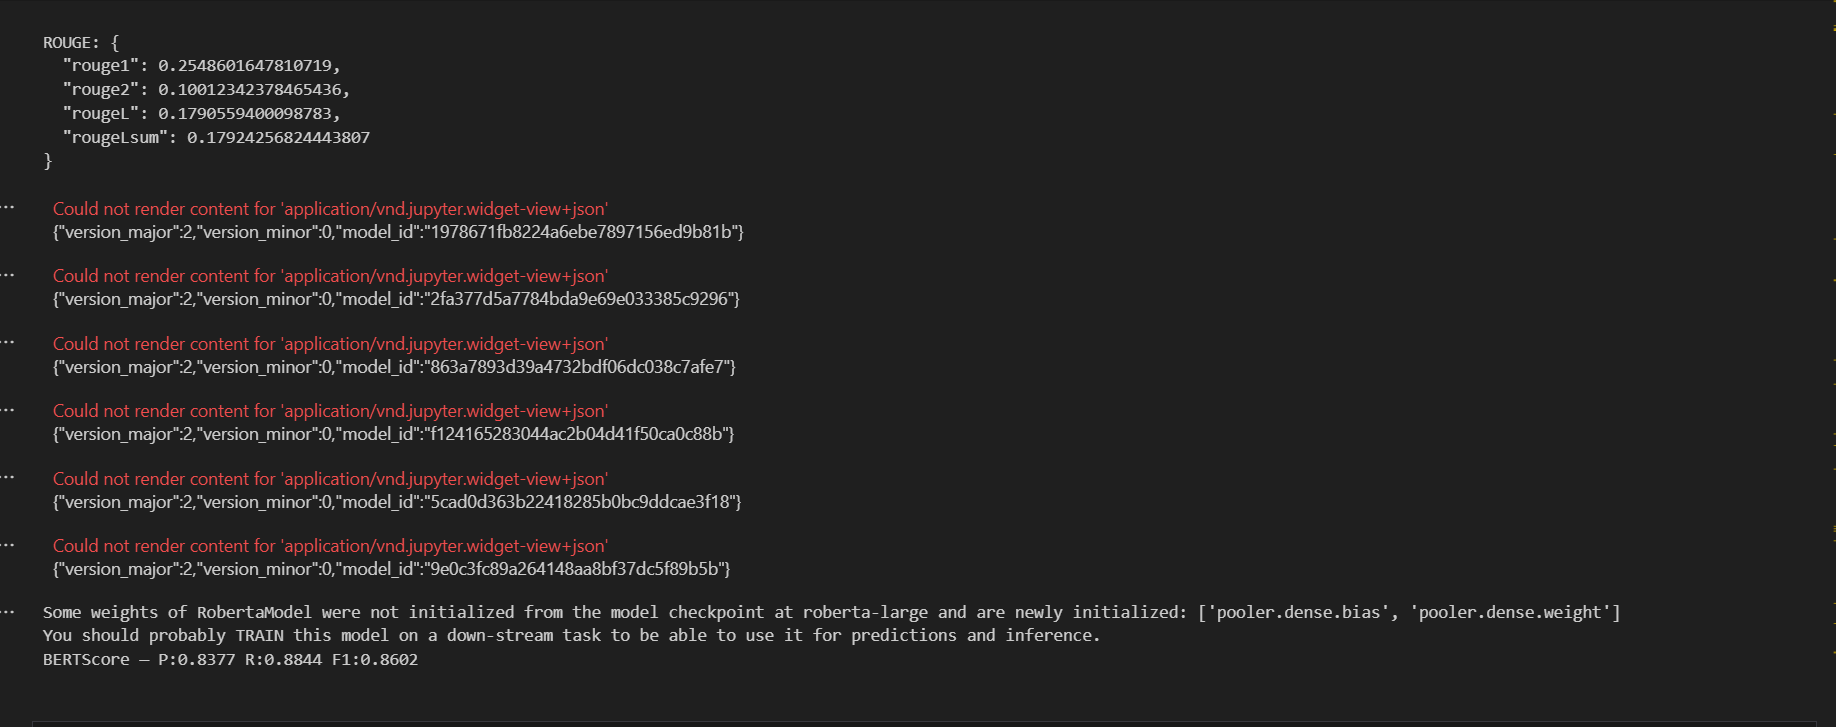

In [58]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.8 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.3 MB/s eta 0:00:00:00:0100:01


In [60]:
%%writefile app.py

!streamlit run app.py --server.port 8501 --server.address 0.0.0.0


Writing app.py


In [67]:
!fuser -k 8501/tcp || true


In [68]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.baseUrlPath=/proxy/8501/ \
  --server.enableCORS false \
  --server.enableXsrfProtection false





  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501/proxy/8501

^C
  Stopping...
